# ViDA Adaptation on IDRiD (RETFound DINOv2 ViT-L)
Homeostatic Visual Domain Adapter with dual-branch adapters and symmetric KL consistency loss.

In [1]:
import torch
torch.cuda.empty_cache()

In [ ]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/vida/idrid.yaml')

print('Dataset:', config.target_dataset.name)
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Dataset: idrid
Method: vida
Output: ./outputs/vida/idrid/
HF_TOKEN set


In [4]:
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-08-06 10:37:39,001 - src.evaluation.runner.single - INFO - Starting CTTA adaptation on dataset: idrid
2026-08-06 10:37:43,404 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/YukunZhou/RETFound_dinov2_meh/resolve/main/RETFound_dinov2_meh.pth "HTTP/1.1 302 Found"
2026-08-06 10:37:43,573 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/YukunZhou/RETFound_dinov2_meh/xet-read-token/6dff4c76632983267a6ae3000f7852b1f8667d9c "HTTP/1.1 200 OK"


RETFound_dinov2_meh.pth:   0%|          | 0.00/1.61G [00:00<?, ?B/s]

2026-08-06 10:37:52,095 - src.models.retfound - INFO - Extracted state_dict from DINOv2 'teacher' key
2026-08-06 10:37:52,096 - src.models.retfound - INFO - Stripped 'backbone.' prefix from 359 state dict keys
2026-08-06 10:37:52,097 - src.models.retfound - INFO - RETFound checkpoint cached in CPU RAM
2026-08-06 10:37:52,255 - src.models.retfound - INFO - Feature normalization ENABLED in forward() (required for prototype classifier)
2026-08-06 10:37:52,972 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-06 10:38:32,009 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=100.0
2026-08-06 10:38:32,012 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 413 training samples (5 classes, 1024-dim features, T=100.0)
2026-08-06 10:38:32,068 - src.evaluation.runner.single - INFO - Classifier initialized with training-set prototypes
2026-08-06 10:38:32,068 - src.evaluation.runner.single - INFO - Evaluating baseline on idri

Adapting to idrid:   0%|          | 0/7 [00:00<?, ?it/s]

2026-08-06 10:39:00,501 - src.evaluation.runner.single - INFO -   Adapt step 0: loss=0.2210, kl=0.0025, ce=0.7282, conf=0.06, unc=0.4355, lam_low=0.565, lam_high=1.435, restored=19253


...

Adapting to idrid:  86%|████████▌ | 6/7 [01:47<00:18, 18.59s/it, acc=0.5000, adaptations=6]

2026-08-06 10:40:38,519 - src.evaluation.runner.single - INFO -   Adapt step 6: loss=0.0088, kl=0.0088, ce=0.0000, conf=0.00, unc=0.6045, lam_low=0.396, lam_high=1.604, restored=19444


Adapting to idrid: 100%|██████████| 7/7 [01:55<00:00, 16.43s/it, acc=0.4286, adaptations=7]

2026-08-06 10:40:38,974 - src.evaluation.runner.single - INFO - Evaluating after adaptation on idrid


2026-08-06 10:40:50,538 - src.evaluation.runner.single - INFO - Post-adaptation QWK: 0.5693
2026-08-06 10:40:50,540 - src.evaluation.runner.single - INFO - Adaptations: 7/7
2026-08-06 10:40:50,610 - src.evaluation.runner.base - INFO - Results saved to outputs/vida/idrid/ctta_results.json


In [5]:
print('=== Results ===')
print(f'Baseline QWK:        {results["baseline_metrics"]["qwk"]:.4f}')
print(f'Baseline Accuracy:   {results["baseline_metrics"]["overall_accuracy"]*100:.2f}%')
print(f'Post-adapt QWK:      {results["final_metrics"]["qwk"]:.4f}')
print(f'Post-adapt Accuracy: {results["final_metrics"]["overall_accuracy"]*100:.2f}%')
dr = results['domain_result']
print(f'Adaptations:          {dr["num_adaptations"]}/{dr["total_batches"]}')
print(f'Adaptation rate:      {results.get("adaptation_rate", 0)*100:.2f}%')

gap = results['final_metrics']['qwk'] - results['baseline_metrics']['qwk']
print(f'QWK change:           {gap:+.4f}')
acc_gap = results['final_metrics']['overall_accuracy'] - results['baseline_metrics']['overall_accuracy']
print(f'Accuracy change:      {acc_gap*100:+.2f}%')

=== Results ===
Baseline QWK:        0.5307
Baseline Accuracy:   42.72%
Post-adapt QWK:      0.5693
Post-adapt Accuracy: 44.66%
Adaptations:          7/7
Adaptation rate:      100.00%
QWK change:           +0.0385
Accuracy change:      +1.94%


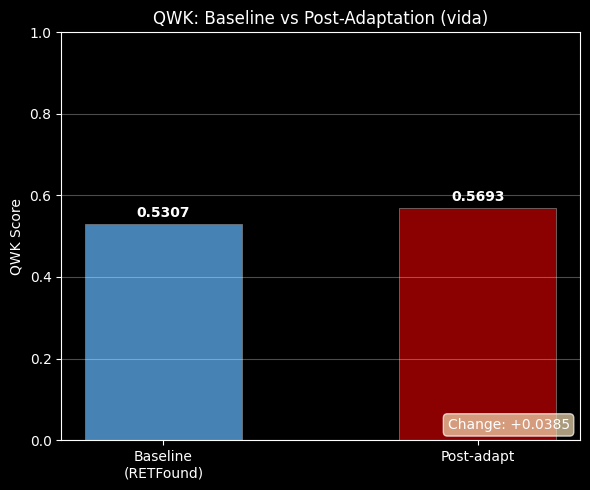

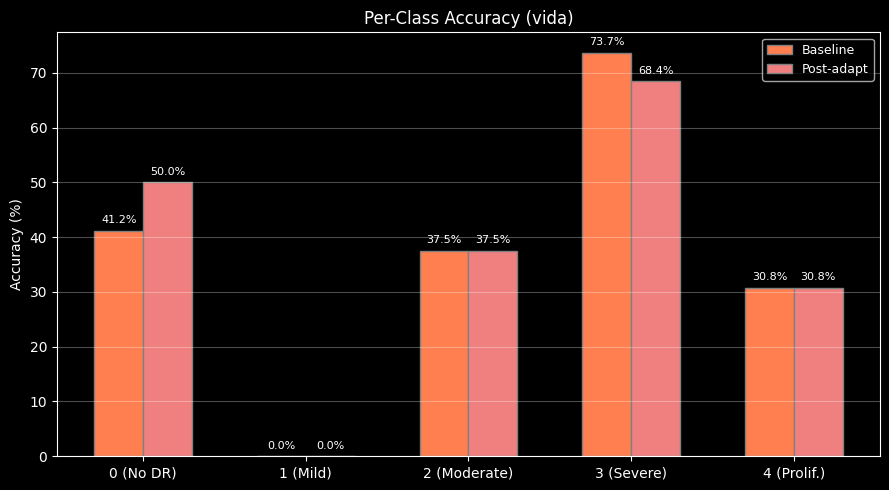

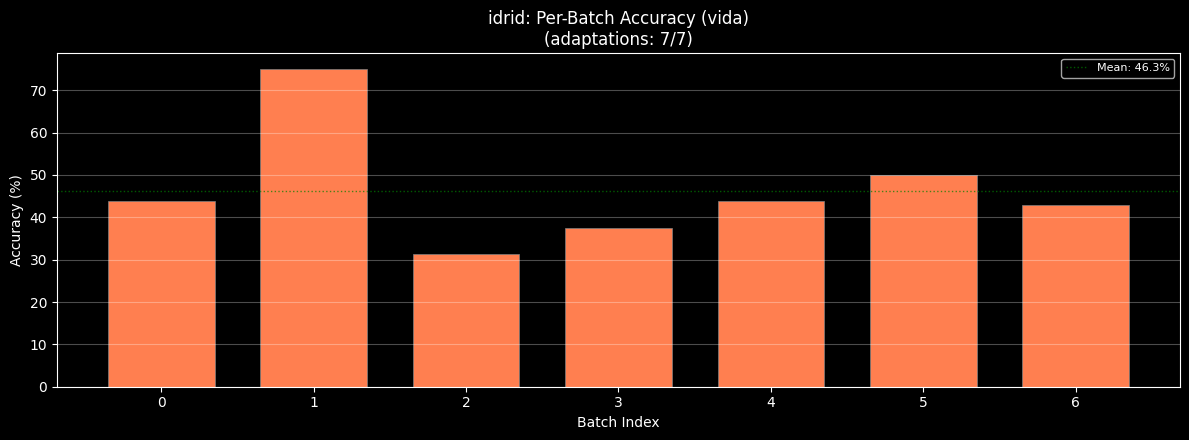

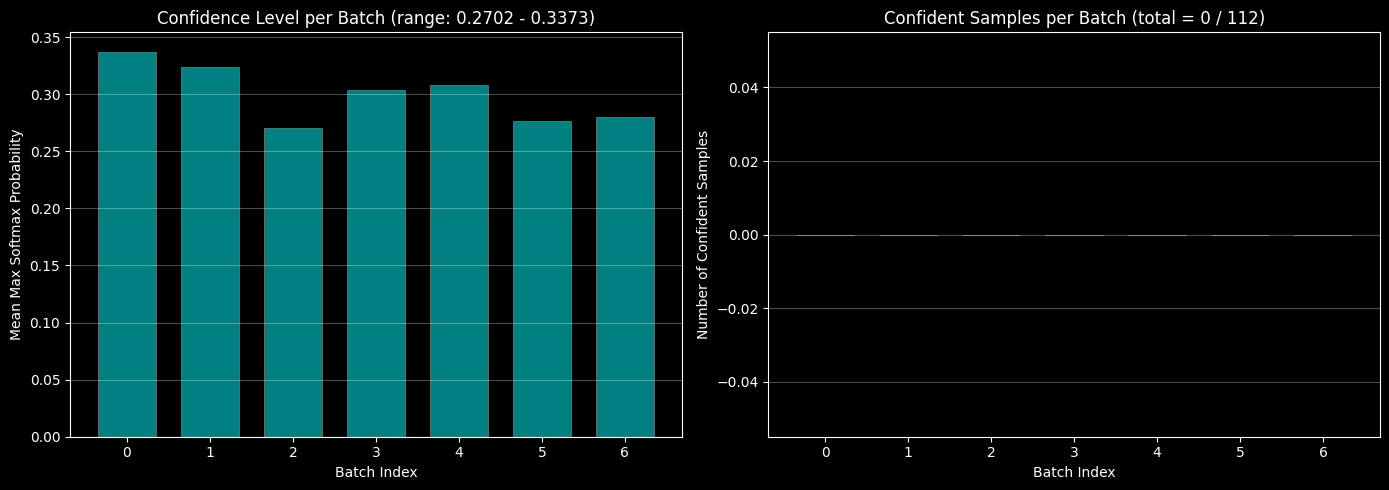

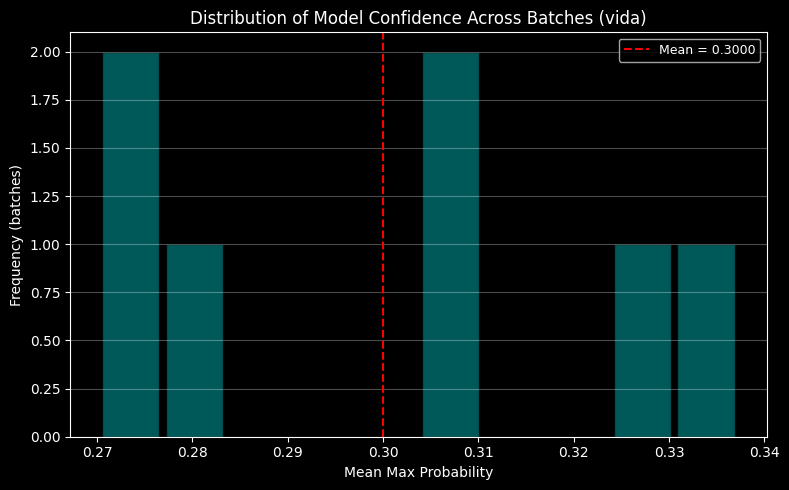

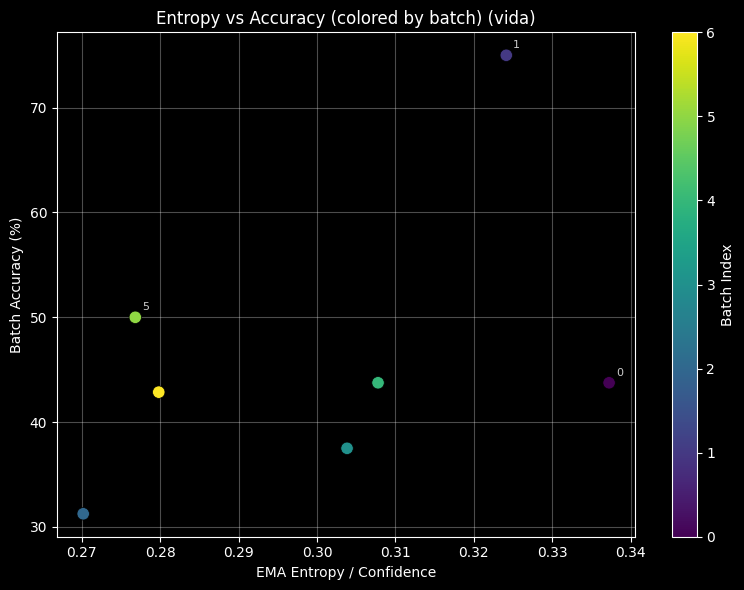

====================== CTTA Results (vida) ======================
Baseline QWK:       0.5307
Post-adapt QWK:     0.5693
Adaptations:        7/7
Adaptation rate:    100.00%
QWK change:         +0.0385
Mean batch acc:     46.3%


In [6]:
from src.viz import (
    get_domain_data, plot_qwk_bar, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table, plot_per_class_accuracy as plot_pca,
)

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

dr = results['domain_result']
method = results.get("method", "")

plot_qwk_bar(results, plots_dir, method_name=method)
plot_pca(results, dr, plots_dir, method_name=method)
plot_per_batch_accuracy(dr, None, plots_dir, method_name=method)
plot_adaptation_metrics(dr['adaptation_steps'], plots_dir)
plot_confidence_distribution(dr['adaptation_steps'], plots_dir, method_name=method)
plot_entropy_vs_accuracy(dr['adaptation_steps'], dr['batch_metrics'], plots_dir, method_name=method)
print_summary_table(results, method_name=method)